# 02 - One input space for four different graphs

**What this step does.** Turns four incompatible feature matrices - 1433 dims
for Cora, 745 for Photo, 50 for PPI, 165 for Elliptic - into one shared
**133-dimensional** input space that a single encoder can consume, and proves
with a test that no test-split node leaked into any fitted transform.

**Why it exists.** The research question needs *one shared encoder*. An
encoder has a fixed input width, so four different widths is an immediate,
hard blocker. But making the widths match is the easy half. The hard half is
making them match *without cheating*: the moment a test node's features help
choose the compression basis, information about the test set is baked into
every node's representation and every result afterwards is optimistic by an
amount nobody can measure.

The recipe has two halves:

| | what | why |
|---|---|---|
| 128 dims | per-domain TruncatedSVD of the raw features | compresses *content* to a common width |
| 5 dims | log1p(degree), clustering, PageRank, k-core, triangles | adds *structure*, which the raw features do not describe |
| scaling | one scalar per domain on the SVD block | equal width is not equal footing - see section 6 |

**What could go wrong.**
- **Leakage through a fitted transform.** The main risk, and the reason for
  the test suite below. It is invisible - nothing crashes, the numbers just
  come out too good.
- **Confusing "uses the whole graph" with "leaks".** Structural features are
  computed from every edge, including edges touching test nodes. That is not
  leakage; it is the standard transductive setting, and those features never
  look at a label. The distinction is made precise below.
- **Assuming 128 dims is free.** It is not. For Cora it discards nearly half
  the variance, and PPI cannot even produce 128 components from 50 features.
- **Silently ignoring scale.** Four domains can all be 133-wide and still
  arrive at the encoder on wildly different scales, which would let one
  domain dominate the shared pretraining.

## Setup

In [1]:
import pathlib
import sys

_here = pathlib.Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [_here, *_here.parents] if (p / "src" / "config.py").exists())
sys.path.insert(0, str(PROJECT_ROOT)) if str(PROJECT_ROOT) not in sys.path else None

import numpy as np
import pandas as pd

from src import config, datasets, features, plotting, splits
from src.seeding import set_seed

SEED = 0
set_seed(SEED)
plotting.use_project_style()
pd.set_option("display.width", 170)

domains_raw = datasets.load_all_domains(verbose=False)
print("loaded:", {n: d.num_raw_features for n, d in domains_raw.items()})
print("device:", config.get_device())

loaded: {'cora': 1433, 'photo': 745, 'ppi': 50, 'elliptic': 165}
device: cuda


## 1. First: make Elliptic undirected

Notebook 01 found that Elliptic is the only directed domain, and that **27% of
its nodes have no incoming edge**. A GIN layer aggregates over incoming edges,
so those 55,322 nodes would receive no messages at all - their embedding would
be a function of their own features alone, with the graph contributing nothing.

We symmetrize. It is a real trade and worth naming: it discards flow
direction, which is arguably signal in a fraud graph. We take it because three
of the five structural features below (clustering, k-core, triangles) are
undirected notions anyway, and because a shared encoder should not have to
cope with one domain behaving structurally unlike the other three.

In [2]:
domains = {name: features.symmetrize_domain(d) for name, d in domains_raw.items()}

print()
for name, d in domains.items():
    print(f"  {name:<9} undirected now: {d.is_undirected}")

  cora      already undirected, unchanged
  photo     already undirected, unchanged


  ppi       already undirected, unchanged
  elliptic  symmetrised: 234,355 -> 468,710 edge_index columns

  cora      undirected now: True
  photo     undirected now: True


  ppi       undirected now: True
  elliptic  undirected now: True


## 2. Splits come first, because everything is fit on train only

This is the ordering that makes the no-leakage property possible. We cannot
fit the SVD before we know which nodes are training nodes.

Two rules encoded in `src/splits.py`:

- **Only scorable nodes go into a split.** Elliptic's 157,205 "unknown" nodes
  are excluded from train, validation *and* test. They stay in the graph and
  keep contributing to message passing - they simply can never be scored.
- **Stratify where it is meaningful.** Elliptic is 9.2x imbalanced; a plain
  random split could leave the rare class badly represented in validation,
  making early stopping erratic. PPI is multi-label (~37 of 121 labels active
  per node), so there is no single class to stratify on and it gets a random
  split.

In [3]:
node_splits = {name: splits.make_node_split(d, seed=SEED) for name, d in domains.items()}

for name, d in domains.items():
    splits.print_split_summary(d, node_splits[name])


--- cora (seed 0) ---
  total nodes      : 2,708
  scorable nodes   : 2,708
  train/val/test   : 1,624 / 542 / 542
  stratified       : True
  class balance holds across splits:
            c0       c1       c2       c3       c4       c5       c6
  train    0.129    0.080    0.155    0.302    0.157    0.110    0.067
  val      0.129    0.081    0.155    0.303    0.157    0.109    0.066
  test     0.131    0.079    0.153    0.301    0.159    0.111    0.066

--- photo (seed 0) ---
  total nodes      : 7,650
  scorable nodes   : 7,650
  train/val/test   : 4,590 / 1,530 / 1,530
  stratified       : True
  class balance holds across splits:
            c0       c1       c2       c3       c4       c5       c6       c7
  train    0.048    0.221    0.092    0.120    0.115    0.108    0.254    0.043
  val      0.048    0.220    0.091    0.120    0.115    0.108    0.254    0.043
  test     0.048    0.220    0.092    0.120    0.116    0.107    0.254    0.043

--- ppi (seed 0) ---
  total nodes  

## 3. The five structural features

The raw features describe a node's *content* - the words in a paper, the
reviews of a product. They say nothing about where the node sits in the graph.
These five add that, and all five are **label-free**: none of them can be
computed from `y`, so none of them can leak a label.

| feature | plain meaning |
|---|---|
| `log1p_degree` | how many neighbours. Logged because degree is heavy-tailed - Photo has a node with 1434 neighbours and a median of 22. |
| `clustering` | do my neighbours know each other? The fraction of my neighbour-pairs that are themselves connected. |
| `pagerank` | how likely a random walker is to be sitting on me. Importance that accounts for *whose* neighbour I am, not just how many. |
| `kcore` | how deeply embedded I am. Peel away every node of degree < k repeatedly; my core number is the largest k I survive. |
| `triangles` | how many triangles pass through me. |

Degree and k-core are not the same thing, and the difference matters. A hub
with 500 neighbours that are all leaves has enormous degree but a core number
of 1 - peel the leaves and nothing holds it up. Notebook 07 leans on exactly
this kind of distinction when asking whether structurally similar domains
transfer better.

In [4]:
structural = {name: features.structural_features_for_domain(d) for name, d in domains.items()}

print()
print("shape check - (nodes, 5) per domain:")
for name, s in structural.items():
    print(f"  {name:<9} {s.shape}  dtype={s.dtype}  finite={np.isfinite(s).all()}")

  cora      structural features (2708, 5) in 0.2s


  photo     structural features (7650, 5) in 0.5s


  ppi       structural features (56944, 5) in 4.0s


  elliptic  structural features (203769, 5) in 2.0s

shape check - (nodes, 5) per domain:
  cora      (2708, 5)  dtype=float32  finite=True
  photo     (7650, 5)  dtype=float32  finite=True
  ppi       (56944, 5)  dtype=float32  finite=True
  elliptic  (203769, 5)  dtype=float32  finite=True


Let us look at the actual numbers for a few nodes, rather than trusting the
shape. Note how differently the same five columns behave across domains -
Cora's clustering is near zero (papers rarely cite in triangles), Photo's is
high (co-purchased products cluster hard).

In [5]:
for name, s in structural.items():
    df = pd.DataFrame(s[:3], columns=features.STRUCTURAL_NAMES)
    print(f"\n--- {name}: first 3 nodes ---")
    print(df.to_string(index=True, float_format=lambda v: f"{v:.5g}"))

print("\n\n--- median of each structural feature, per domain ---")
med = pd.DataFrame(
    {name: np.median(s, axis=0) for name, s in structural.items()},
    index=features.STRUCTURAL_NAMES,
).T
print(med.to_string(float_format=lambda v: f"{v:.5g}"))


--- cora: first 3 nodes ---
   log1p_degree  clustering   pagerank  kcore  triangles
0        1.3863     0.33333 0.00033504      2          1
1        1.3863           0 0.00038425      2          0
2        1.7918           0 0.00051449      3          0

--- photo: first 3 nodes ---
   log1p_degree  clustering   pagerank  kcore  triangles
0        2.3979     0.55556 4.7521e-05     10         25
1        2.8904     0.45588 7.5533e-05     16         62
2        2.3026     0.36111 0.00010074      7         13

--- ppi: first 3 nodes ---
   log1p_degree  clustering   pagerank  kcore  triangles
0        1.3863           0  0.0001774      3          0
1         3.434     0.23678 0.00081185     20        103
2        2.3026     0.16667 0.00045451      7          6

--- elliptic: first 3 nodes ---
   log1p_degree  clustering   pagerank  kcore  triangles
0        1.0986           0  5.063e-06      1          0
1        1.0986           0 5.5008e-06      1          0
2        1.3863          

saved -> D:\documents\my projects\afterPFE\OmniGraph\results\figures\02_structural_features.png


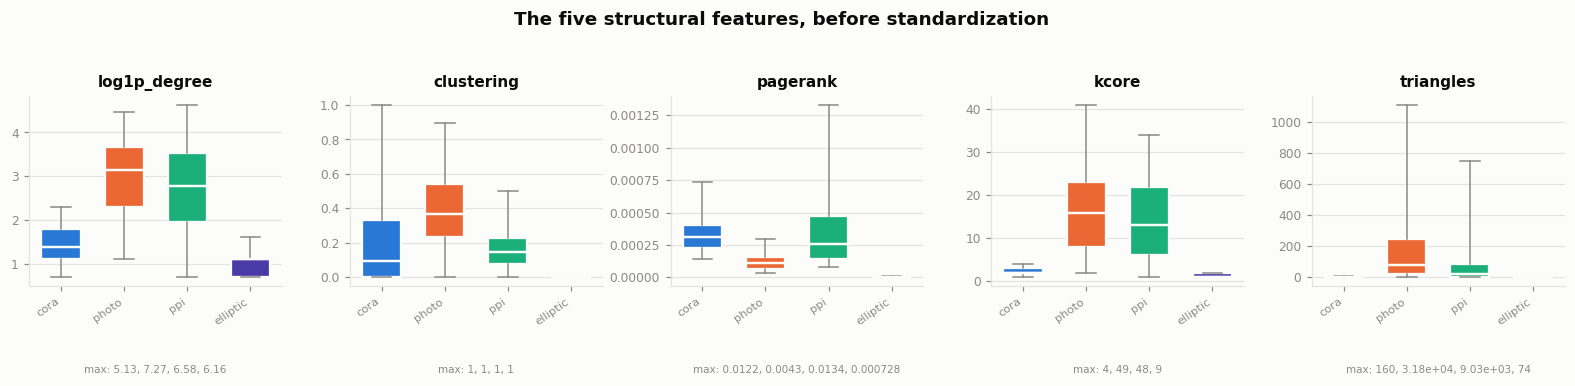

In [6]:
fig = plotting.plot_structural_distributions(structural, features.STRUCTURAL_NAMES)

## 4. The crux: SVD fit on training nodes only

TruncatedSVD rather than PCA, for a concrete reason. PCA centres the data
first, and centring a sparse matrix makes it dense - for Cora that turns a
2708x1433 matrix that is 98.7% zeros into a fully dense one. TruncatedSVD
works directly on the sparse matrix without centring.

The important line in `src/features.py` is this one:

```python
self.svd.fit(x[train_idx])       # train rows only, never val or test
```

Watch what happens to PPI below. It has only 50 raw features, and
TruncatedSVD cannot produce more components than the data has dimensions - so
it yields 49 and we zero-pad the remaining 79 to keep the width identical
across domains. Padding with zeros adds no information; it just aligns the
shape.

In [7]:
unified, transforms = {}, {}
for name, d in domains.items():
    u, tr, _ = features.build_unified_features(
        d, node_splits[name], seed=SEED, structural=structural[name]
    )
    unified[name], transforms[name] = u, tr

print()
print("every domain now has the same input width:")
for name, u in unified.items():
    print(f"  {name:<9} {u.shape}   = 128 SVD + 5 structural")

  cora      SVD 1433 -> 128 dims  | explains 52.8% of variance | /0.266  | fit on 1,624 train nodes


  photo     SVD 745 -> 128 dims  | explains 58.7% of variance | /0.859  | fit on 4,590 train nodes
  ppi       SVD 50 -> 49 dims, zero-padding 79  | explains 100.0% of variance | /0.996  | fit on 34,166 train nodes


  elliptic  SVD 165 -> 128 dims  | explains 100.0% of variance | /1.601  | fit on 27,938 train nodes



every domain now has the same input width:
  cora      (2708, 133)   = 128 SVD + 5 structural
  photo     (7650, 133)   = 128 SVD + 5 structural
  ppi       (56944, 133)   = 128 SVD + 5 structural
  elliptic  (203769, 133)   = 128 SVD + 5 structural


### What the compression actually cost

The explained-variance numbers above are not decoration. Cora and Photo lose a
lot; PPI and Elliptic lose essentially nothing. This asymmetry is a real
property of the design and should be remembered when reading results: if
transfer to Cora turns out weak, "we threw away 47% of Cora's feature variance
before the encoder ever saw it" is a candidate explanation.

In [8]:
summary = pd.DataFrame([
    {
        "domain": name,
        "raw_dim": tr.raw_dim,
        "svd_components": tr.n_components_used,
        "zero_padded": tr.padded_dims,
        "variance_explained": tr.explained_variance,
        "variance_discarded": 1 - tr.explained_variance,
        "fit_on_nodes": len(tr.fitted_on),
        "output_dim": tr.output_dim,
    }
    for name, tr in transforms.items()
]).set_index("domain")

display(summary.style.format({
    "variance_explained": "{:.2%}",
    "variance_discarded": "{:.2%}",
    "fit_on_nodes": "{:,}",
}))

,raw_dim,svd_components,zero_padded,variance_explained,variance_discarded,fit_on_nodes,output_dim
domain,,,,,,,
cora,1433,128,0,52.76%,47.24%,"1,624",133
photo,745,128,0,58.72%,41.28%,"4,590",133
ppi,50,49,79,99.99%,0.01%,"34,166",133
elliptic,165,128,0,99.99%,0.01%,"27,938",133


saved -> D:\documents\my projects\afterPFE\OmniGraph\results\figures\02_svd_spectrum.png


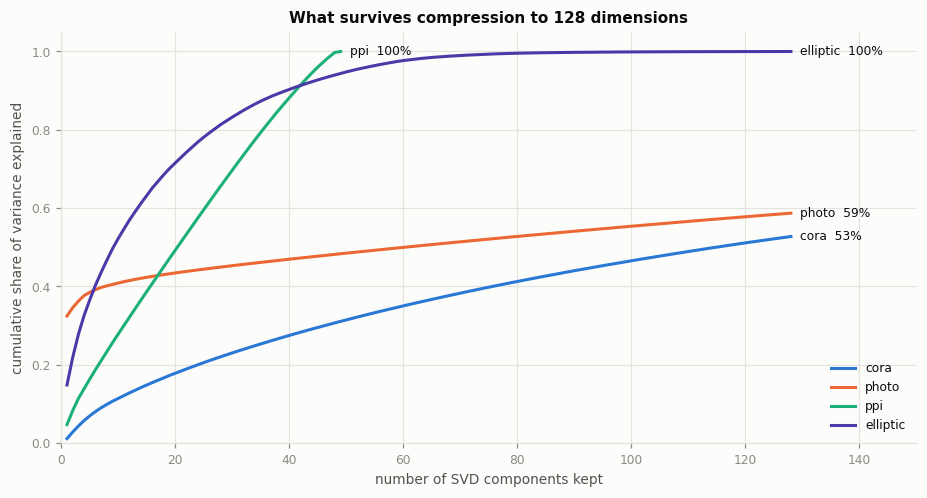

In [9]:
fig = plotting.plot_svd_spectrum(transforms)

## 5. Before and after

Shapes and dtypes for one domain, so the transformation is concrete rather
than abstract.

In [10]:
name = "cora"
d = domains[name]
import torch
raw = torch.cat([g.x for g in d.graphs], dim=0).numpy()

print(f"--- {name} ---")
print(f"BEFORE  shape={raw.shape}  dtype={raw.dtype}  "
      f"sparsity={(raw == 0).mean():.4f}  range=[{raw.min():.3g}, {raw.max():.3g}]")
print(f"AFTER   shape={unified[name].shape}  dtype={unified[name].dtype}  "
      f"sparsity={(unified[name] == 0).mean():.4f}  "
      f"range=[{unified[name].min():.3g}, {unified[name].max():.3g}]")

print(f"\nBEFORE, node 0, first 12 of {raw.shape[1]} dims:")
print("  ", np.array2string(raw[0, :12], precision=3, suppress_small=True))
print(f"\nAFTER, node 0 -- first 8 SVD dims, then all 5 structural dims:")
print("   SVD       :", np.array2string(unified[name][0, :8], precision=3))
print("   structural:", np.array2string(unified[name][0, 128:], precision=3))
print(f"\n   (structural dims are standardized, so ~0 means 'average for this domain')")

--- cora ---
BEFORE  shape=(2708, 1433)  dtype=float32  sparsity=0.9873  range=[0, 1]
AFTER   shape=(2708, 133)  dtype=float32  sparsity=0.0000  range=[-5.31, 28.7]

BEFORE, node 0, first 12 of 1433 dims:
   [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

AFTER, node 0 -- first 8 SVD dims, then all 5 structural dims:
   SVD       : [ 1.846  4.588 -0.304  0.618 -1.279  0.101 -0.523 -0.03 ]
   structural: [-0.026  0.296 -0.078 -0.342 -0.151]

   (structural dims are standardized, so ~0 means 'average for this domain')


## 6. Equal width is not equal footing

Making all four domains 133-wide was necessary but is not sufficient. The
encoder sees all four of these matrices. If one domain's inputs are much
larger in magnitude than another's, the round-robin multi-domain pretraining
in notebook 03 will be dominated by whichever domain shouts loudest, and "one
shared encoder" quietly becomes "an encoder mostly fitted to one domain".

There are two separate imbalances to check for, and raw SVD output has both:

1. **Across domains.** Photo's leading component has standard deviation 7.2;
   Cora's largest is 0.53.
2. **Within a domain, content versus structure.** The 5 structural features
   are standardized to ~1.0. If Cora's 128 content dimensions all sit around
   0.25, then 5 structural features outweigh 128 content features.

The cell below measures both, with no correction applied.

In [11]:
def scale_report(scaling):
    """RMS standard deviation of each block, per domain."""
    rows = []
    for name, d in domains.items():
        u, tr, _ = features.build_unified_features(
            d, node_splits[name], seed=SEED, svd_scaling=scaling,
            structural=structural[name], verbose=False,
        )
        live = u[:, :tr.n_components_used]          # exclude zero padding
        content = float(np.sqrt(live.var(axis=0).mean()))
        struct = float(np.sqrt(u[:, 128:].var(axis=0).mean()))
        rows.append({
            "domain": name,
            "content_rms": content,
            "structural_rms": struct,
            "content_vs_structural": content / struct,
            "largest_single_dim": float(live.std(axis=0).max()),
        })
    return pd.DataFrame(rows).set_index("domain")

before = scale_report("none")
display(before.style.format("{:.3f}").set_caption("BEFORE: raw SVD output"))

spread = before["content_rms"].max() / before["content_rms"].min()
print(f"\nContent-block scale spread across domains: {spread:.1f}x")
print(f"Cora content-vs-structural ratio: {before.loc['cora', 'content_vs_structural']:.2f}"
      f"  <- 5 structural features outweigh 128 content features")

,content_rms,structural_rms,content_vs_structural,largest_single_dim
domain,,,,
cora,0.253,0.949,0.267,0.534
photo,0.838,0.963,0.870,7.177
ppi,0.998,1.011,0.987,1.516
elliptic,1.132,1.049,1.079,4.032



Content-block scale spread across domains: 4.5x
Cora content-vs-structural ratio: 0.27  <- 5 structural features outweigh 128 content features


### The correction, and why it is one scalar

We divide each domain's whole SVD block by **a single number**, chosen so the
retained components have root-mean-square standard deviation 1. Computed on
training rows only, like every other fitted quantity here.

The obvious alternative is a `StandardScaler` over the 128 columns, giving
every dimension mean 0 and variance 1 individually. That is the more
conventional choice and it is available as `svd_scaling="per_dim"`, but it is
the wrong default here, for a specific reason:

> SVD components come out **ordered by importance**. Component 0 carries far
> more signal than component 127. Standardizing per dimension forces them to
> equal scale - it amplifies the near-noise trailing components to full
> strength and throws away exactly the ordering SVD exists to produce. For
> Cora, which retains only 53% of its variance across 128 dims, those trailing
> components are mostly noise.

One scalar fixes both imbalances while leaving the spectrum's shape untouched:
every ratio between components is exactly preserved. `tests/test_no_leakage.py`
asserts both properties.

In [12]:
after = scale_report("block")
display(after.style.format("{:.3f}").set_caption("AFTER: block scaling"))

spread_after = after["content_rms"].max() / after["content_rms"].min()
print(f"\nContent-block scale spread:  {spread:.1f}x  ->  {spread_after:.1f}x")
print("content-vs-structural ratio, per domain:")
for name in after.index:
    print(f"    {name:<9} {before.loc[name, 'content_vs_structural']:.2f}  ->  "
          f"{after.loc[name, 'content_vs_structural']:.2f}")

print("\nElliptic lands at 0.67 rather than 1.00, and that is correct, not a bug:")
print("the scalar is fit on its 27,938 labelled TRAINING nodes, but applied to")
print("all 203,769 nodes. The 157,205 unlabelled ones have different feature")
print("statistics. Fitting on everything would make this land at exactly 1.00")
print("-- and would be leakage.")

,content_rms,structural_rms,content_vs_structural,largest_single_dim
domain,,,,
cora,0.952,0.949,1.002,2.005
photo,0.976,0.963,1.013,8.354
ppi,1.002,1.011,0.990,1.522
elliptic,0.707,1.049,0.674,2.518



Content-block scale spread:  4.5x  ->  1.4x
content-vs-structural ratio, per domain:
    cora      0.27  ->  1.00
    photo     0.87  ->  1.01
    ppi       0.99  ->  0.99
    elliptic  1.08  ->  0.67

Elliptic lands at 0.67 rather than 1.00, and that is correct, not a bug:
the scalar is fit on its 27,938 labelled TRAINING nodes, but applied to
all 203,769 nodes. The 157,205 unlabelled ones have different feature
statistics. Fitting on everything would make this land at exactly 1.00
-- and would be leakage.


Rebuild the features with the correction applied. This is what notebook 03
onwards consumes.

Below, the standard deviation of each of the 133 dimensions per domain, on a
log axis. The flat region in the PPI panel is its 79 zero-padded dimensions -
scaling is applied *before* padding, so those stay exactly zero rather than
picking up a spurious offset.

  cora      SVD 1433 -> 128 dims  | explains 52.8% of variance | /0.266  | fit on 1,624 train nodes


  photo     SVD 745 -> 128 dims  | explains 58.7% of variance | /0.859  | fit on 4,590 train nodes


  ppi       SVD 50 -> 49 dims, zero-padding 79  | explains 100.0% of variance | /0.996  | fit on 34,166 train nodes


  elliptic  SVD 165 -> 128 dims  | explains 100.0% of variance | /1.601  | fit on 27,938 train nodes


saved -> D:\documents\my projects\afterPFE\OmniGraph\results\figures\02_unified_scales.png


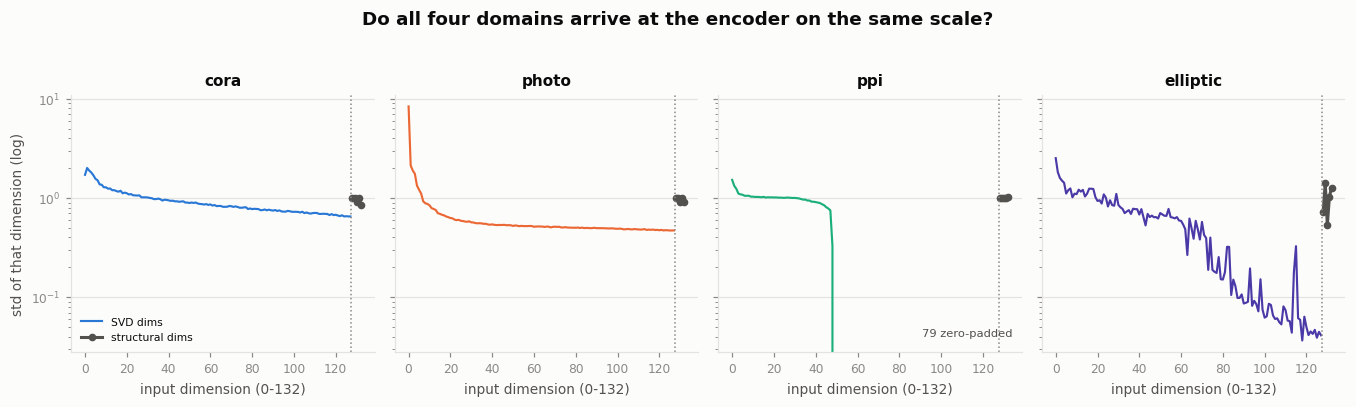

In [13]:
unified, transforms = {}, {}
for name, d in domains.items():
    u, tr, _ = features.build_unified_features(
        d, node_splits[name], seed=SEED, svd_scaling="block",
        structural=structural[name],
    )
    unified[name], transforms[name] = u, tr

fig = plotting.plot_unified_scales(unified, transforms)

## 7. The leakage test

The point of the whole notebook. `tests/test_no_leakage.py` checks this at
three strengths:

1. **Bookkeeping** - the indices recorded as "fitted on" are disjoint from
   validation and test.
2. **Behavioural** - corrupt every test row to loud noise, refit, and require
   the fitted parameters to come out *bit-identical*. If the fit had seen
   those rows, the basis would move. This catches leaks that bookkeeping
   cannot, such as a transform that fits on everything and only *reports*
   the train indices.
3. **Proof the test works** - a deliberately leaky fit (fit on all nodes) is
   required to FAIL the corruption check. Without this, the tests above could
   pass for the boring reason that the corruption was too weak to move
   anything.

There is also a check that shuffling every label leaves all five structural
features bit-identical - the precise statement of "may see the graph, must
never see the labels".

In [14]:
import subprocess

result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/", "-v", "--no-header", "-q"],
    cwd=PROJECT_ROOT, capture_output=True, text=True,
)
print(result.stdout[-4000:])
if result.returncode != 0:
    print(result.stderr[-2000:])
    raise AssertionError("LEAKAGE TESTS FAILED -- do not trust anything downstream")

============================= test session starts =============================
collected 22 items

tests\test_no_leakage.py ......................                          [100%]

============================= 22 passed in 15.02s =============================



And the same assertion inline, on all four domains rather than the two the
test suite uses, so nothing downstream runs on an unverified transform.

In [15]:
for name, tr in transforms.items():
    sp = node_splits[name]
    fitted = set(tr.fitted_on.tolist())
    assert fitted == set(sp.train_idx.tolist()), f"{name}: fitted_on != train set"
    assert not (fitted & set(sp.val_idx.tolist())), f"{name}: fitted on a VAL node"
    assert not (fitted & set(sp.test_idx.tolist())), f"{name}: fitted on a TEST node"
    assert unified[name].shape == (domains[name].total_nodes, 133), f"{name}: wrong width"
    assert np.isfinite(unified[name]).all(), f"{name}: non-finite values"
    print(f"  {name:<9} fit on {len(fitted):>7,} train nodes | "
          f"0 of {len(sp.val_idx):,} val | 0 of {len(sp.test_idx):,} test | "
          f"shape {unified[name].shape}")

print("\nAll four domains: 133 dims, finite, and fitted on training nodes only.")

  cora      fit on   1,624 train nodes | 0 of 542 val | 0 of 542 test | shape (2708, 133)
  photo     fit on   4,590 train nodes | 0 of 1,530 val | 0 of 1,530 test | shape (7650, 133)
  ppi       fit on  34,166 train nodes | 0 of 11,389 val | 0 of 11,389 test | shape (56944, 133)
  elliptic  fit on  27,938 train nodes | 0 of 9,313 val | 0 of 9,313 test | shape (203769, 133)

All four domains: 133 dims, finite, and fitted on training nodes only.


## What you should now understand

- **Four incompatible feature spaces are now one 133-dim space** (128 SVD +
  5 structural), and the SVD basis and the structural scaler were both fit on
  training nodes only - verified behaviourally, by corrupting test rows and
  requiring the fitted parameters not to move by a single bit.
- **"Uses the whole graph" and "leaks" are different things.** Structural
  features read every edge, including edges touching test nodes, and that is
  the ordinary transductive setting. What must never happen is a *fitted*
  object absorbing test rows, or any feature reading `y`. Both are tested.
- **The unification is not free, and it is not symmetric.** Cora loses ~47% of
  its feature variance to reach 128 dims while Elliptic loses almost nothing,
  and PPI cannot fill 128 dims at all so 79 of its inputs are zero. Keep this
  in mind when reading per-domain transfer results.
- **Equal width was not equal footing.** Raw SVD output left the four domains
  4.5x apart in scale, and left Cora's 5 structural features outweighing its
  128 content features. One scalar per domain, fit on training rows, brings
  the spread to 1.4x and content-versus-structure to ~1:1 - without flattening
  the SVD importance ordering the way per-dimension standardization would.

**Next:** `03_encoder_dgi.ipynb` - the GIN encoder and Deep Graph Infomax
explained, trained on one domain, with a loss curve and a t-SNE of the
embeddings before versus after.